# Retail Demand Forecasting — Walmart Dataset

This notebook implements an end-to-end demand forecasting pipeline:
1. Data Loading & Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Development (3 models + hyperparameter tuning)
5. Model Evaluation & Comparison
6. Residual Analysis & Robustness Testing
7. Model Explainability (SHAP + LIME)

**Primary evaluation metric:** WMAE (Weighted Mean Absolute Error) — holiday weeks are penalized 5× as per the Kaggle competition.

# 1. Setup & Configuration
Imports, seed-setting, and constants.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
import lightgbm as lgb
import optuna
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
import sys, os

# Add src to path to import custom metrics module
sys.path.append(os.path.abspath('../src'))
from metrics import mae, rmse, mape, wmae, r2

# Constants
HOLIDAY_WEIGHT = 5
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
print("All libraries loaded successfully.")


All libraries loaded successfully.


# 2. Data Loading & Preprocessing
## 2.1 Loading & Merging CSVs
We load 4 CSV files and merge them into a single unified dataset.
- `stores.csv` → Store metadata (Type A/B/C, Size)
- `train.csv` → Historical weekly sales (421,570 rows)
- `test.csv` → Future weeks to predict (115,064 rows)
- `features.csv` → External features (Temperature, Fuel_Price, MarkDown1-5, CPI, Unemployment)

In [2]:
# Load datasets
stores = pd.read_csv('../data/raw/stores.csv')
train = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'])
test = pd.read_csv('../data/raw/test.csv', parse_dates=['Date'])
features = pd.read_csv('../data/raw/features.csv', parse_dates=['Date'])

print("stores.csv:", stores.shape)
print("train.csv:", train.shape)
print("test.csv:", test.shape)
print("features.csv:", features.shape)

# Merge order: train/test <- stores <- features
train = train.merge(stores, on='Store', how='left')
test = test.merge(stores, on='Store', how='left')

train = train.merge(features, on=['Store', 'Date'], how='left')
test = test.merge(features, on=['Store', 'Date'], how='left')

# Verify IsHoliday columns match after merge
assert (train['IsHoliday_x'] == train['IsHoliday_y']).all(), "IsHoliday mismatch in train!"
assert (test['IsHoliday_x'] == test['IsHoliday_y']).all(), "IsHoliday mismatch in test!"

# Drop duplicate IsHoliday column
train.rename(columns={'IsHoliday_x': 'IsHoliday'}, inplace=True)
train.drop('IsHoliday_y', axis=1, inplace=True)
test.rename(columns={'IsHoliday_x': 'IsHoliday'}, inplace=True)
test.drop('IsHoliday_y', axis=1, inplace=True)

print("\nMerged Train shape:", train.shape)
print("Merged Test shape:", test.shape)
train.head()


stores.csv: (45, 3)
train.csv: (421570, 5)
test.csv: (115064, 4)
features.csv: (8190, 12)

Merged Train shape: (421570, 16)
Merged Test shape: (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


## 2.2 Missing Value Handling
- **MarkDown1-5:** NaN before Nov 2011 because markdown promotions didn't exist yet → fill with `0`.
- **CPI & Unemployment:** NaN in the test period → forward-fill within each store (macroeconomic indicators change slowly).

In [3]:
from IPython.core import pylabtools
# Check missingness before cleaning
print("=== Missing values BEFORE cleaning ===")
display(train.isna().sum())

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
for col in markdown_cols:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

# Forward-fill CPI and Unemployment for test set
test['CPI'] = test.groupby('Store')['CPI'].ffill()
test['Unemployment'] = test.groupby('Store')['Unemployment'].ffill()
# Backfill with last known train value if NaN persists at the beginning
last_cpi_unemp = train.groupby('Store')[['CPI', 'Unemployment']].last().reset_index()
test = test.merge(last_cpi_unemp, on='Store', suffixes=('', '_last'))
test['CPI'] = test['CPI'].fillna(test['CPI_last'])
test['Unemployment'] = test['Unemployment'].fillna(test['Unemployment_last'])
test.drop(['CPI_last', 'Unemployment_last'], axis=1, inplace=True)

print("\n=== Missing values AFTER cleaning ===")
display(train.isna().sum())


=== Missing values BEFORE cleaning ===


Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
dtype: int64


=== Missing values AFTER cleaning ===


Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Type            0
Size            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
dtype: int64

## 2.3 Date-Based Feature Engineering
We extract standard date components and apply **cyclical sine/cosine encoding** so that Week 52 → Week 1 transitions are smooth (no discontinuity).

In [4]:
def engineer_dates(df):
    """Extract date components and apply cyclical encoding."""
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['Day'] = df['Date'].dt.day
    
    # Cyclical encoding for week and month
    df['week_sin'] = np.sin(2 * np.pi * df['WeekOfYear'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['WeekOfYear'] / 52)
    df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    
    return df

train = engineer_dates(train)
test = engineer_dates(test)

# Encode Store Type as ordinal (A=3, B=2, C=1 — larger stores have higher sales)
type_map = {'A': 3, 'B': 2, 'C': 1}
train['Type'] = train['Type'].map(type_map)
test['Type'] = test['Type'].map(type_map)

print("Date features created. Cyclical encoding preview:")
display(train[['Date', 'Year', 'Month', 'WeekOfYear', 'week_sin', 'week_cos']].head())


Date features created. Cyclical encoding preview:


,Date,Year,Month,WeekOfYear,week_sin,week_cos
0,2010-02-05,2010,2,5,0.568065,0.822984
1,2010-02-12,2010,2,6,0.663123,0.748511
2,2010-02-19,2010,2,7,0.748511,0.663123
3,2010-02-26,2010,2,8,0.822984,0.568065
4,2010-03-05,2010,3,9,0.885456,0.464723


# 3. Exploratory Data Analysis (EDA)
We investigate sales trends, seasonal patterns, holiday impacts, correlations, and distribution of the target variable.

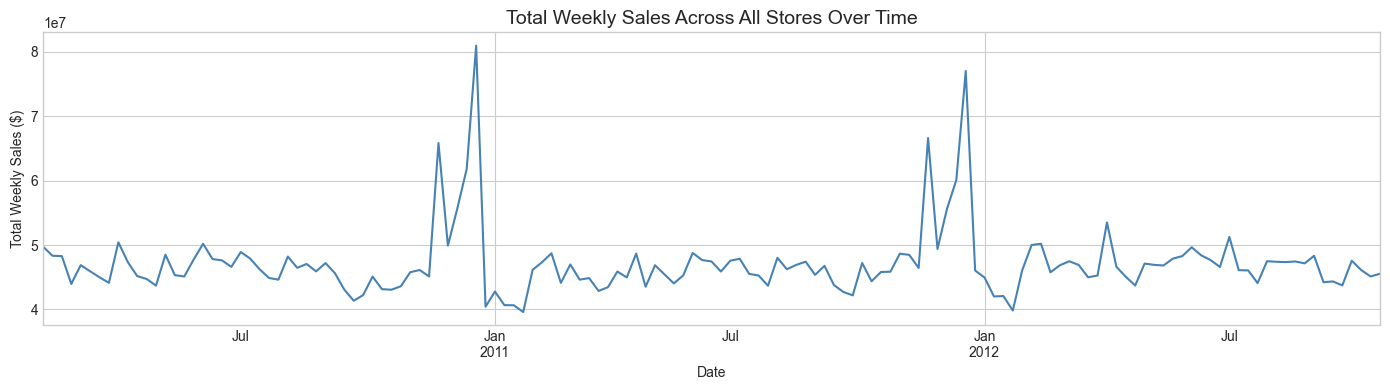

In [5]:
# 3.1 Weekly total sales over time — seasonal patterns
fig, ax = plt.subplots(figsize=(14, 4))
train.groupby('Date')['Weekly_Sales'].sum().plot(ax=ax, color='steelblue')
ax.set_title('Total Weekly Sales Across All Stores Over Time', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Total Weekly Sales ($)')
plt.tight_layout()
plt.show()


**Observation:** Clear yearly seasonality is visible, with massive spikes during the holiday season (Thanksgiving/Christmas) at the end of each year.

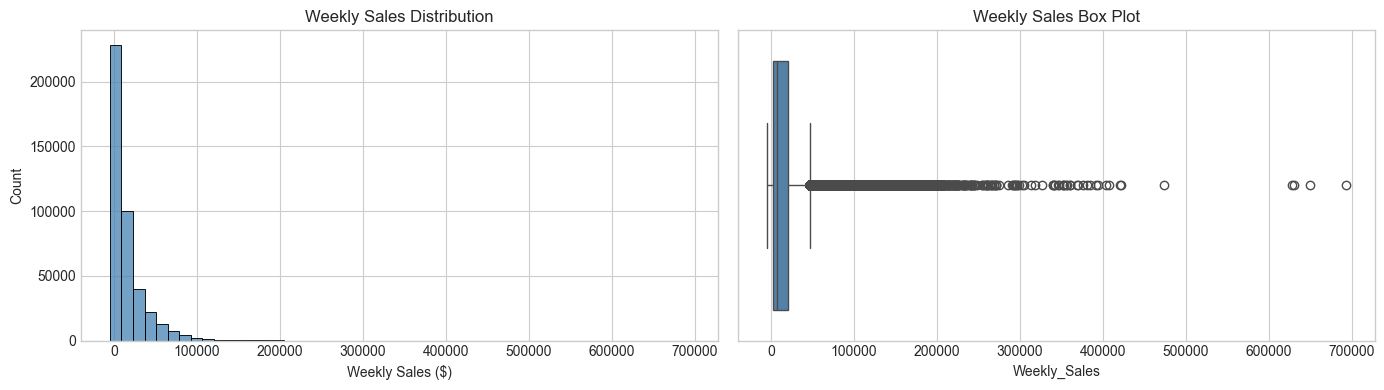

Skewness: 3.26
Kurtosis: 21.49


In [6]:
# 3.2 Distribution of Weekly Sales (target variable)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train['Weekly_Sales'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Weekly Sales Distribution')
axes[0].set_xlabel('Weekly Sales ($)')

sns.boxplot(x=train['Weekly_Sales'], ax=axes[1], color='steelblue')
axes[1].set_title('Weekly Sales Box Plot')
plt.tight_layout()
plt.show()

print(f"Skewness: {train['Weekly_Sales'].skew():.2f}")
print(f"Kurtosis: {train['Weekly_Sales'].kurtosis():.2f}")


**Observation:** The distribution is highly right-skewed with extreme outliers (very high sales weeks). Some departments occasionally have negative sales (likely returns).

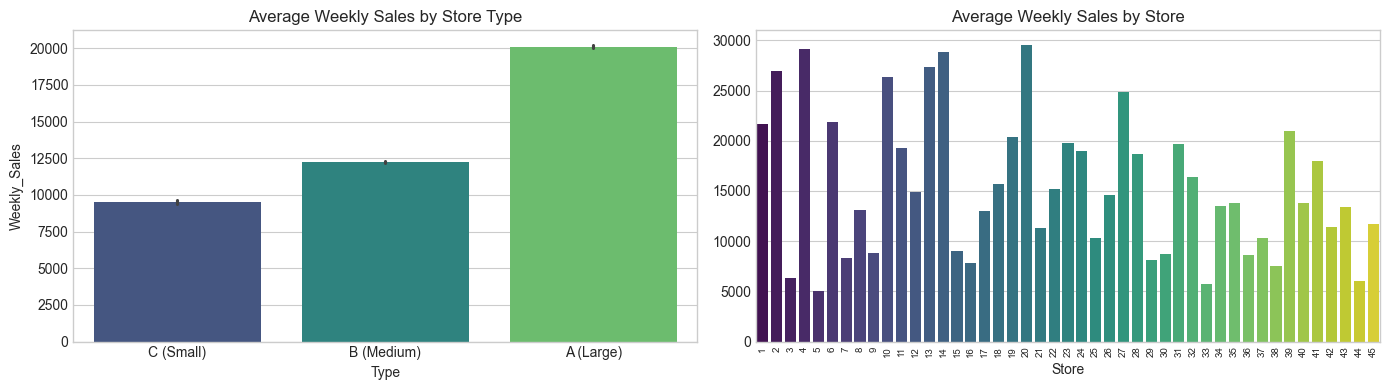

In [7]:
# 3.3 Average sales by Store Type
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x='Type', y='Weekly_Sales', data=train, ax=axes[0], palette='viridis')
axes[0].set_title('Average Weekly Sales by Store Type')
axes[0].set_xticklabels(['C (Small)', 'B (Medium)', 'A (Large)'])

# Sales by store (sorted by average)
store_sales = train.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
sns.barplot(x=store_sales.index, y=store_sales.values, ax=axes[1], palette='viridis')
axes[1].set_title('Average Weekly Sales by Store')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()


**Observation:** Type A stores (largest) have significantly higher average sales. Individual stores show wide variance.

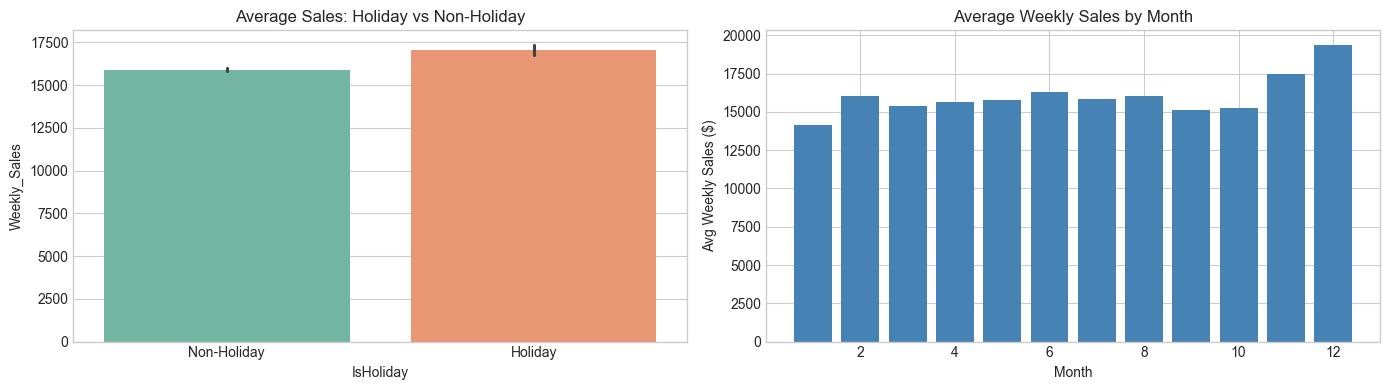

In [8]:
# 3.4 Holiday vs Non-Holiday sales impact
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x='IsHoliday', y='Weekly_Sales', data=train, ax=axes[0], palette='Set2')
axes[0].set_title('Average Sales: Holiday vs Non-Holiday')
axes[0].set_xticklabels(['Non-Holiday', 'Holiday'])

# Monthly sales pattern (seasonal)
monthly = train.groupby('Month')['Weekly_Sales'].mean()
axes[1].bar(monthly.index, monthly.values, color='steelblue')
axes[1].set_title('Average Weekly Sales by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Weekly Sales ($)')
plt.tight_layout()
plt.show()


**Observation:** Holiday weeks have noticeably higher sales. Months 11 (November) and 12 (December) dominate due to Thanksgiving and Christmas.

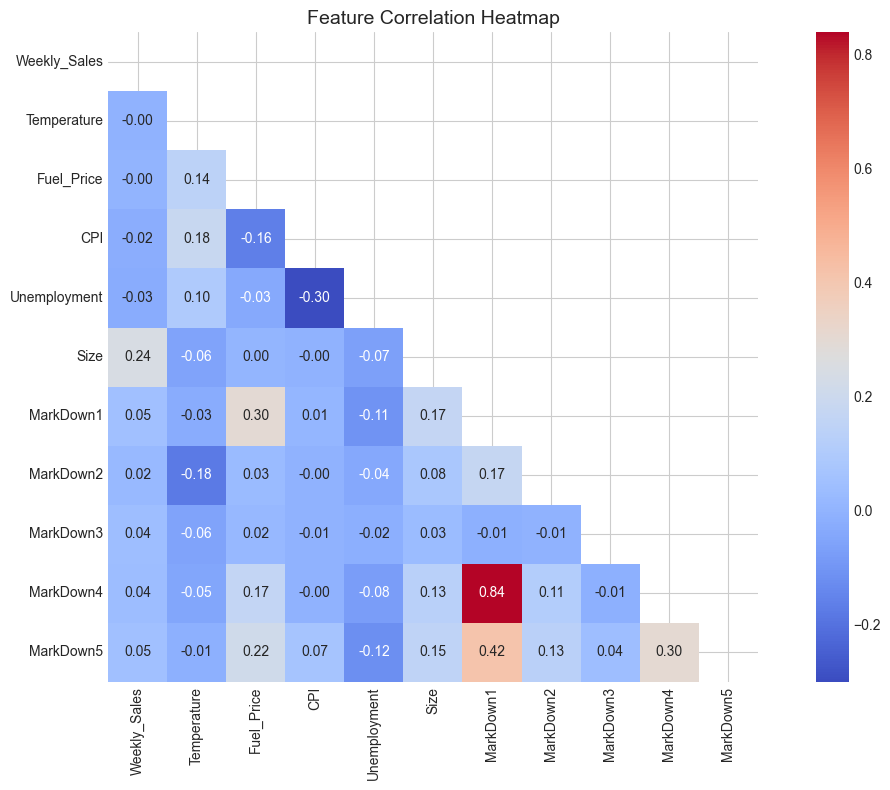

In [9]:
# 3.5 Correlation heatmap
plt.figure(figsize=(12, 8))
corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size'] + markdown_cols
corr_matrix = train[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', mask=mask, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


**Observation:** `Size` has the strongest positive correlation with `Weekly_Sales`. Macro variables (CPI, Unemployment) show weak direct linear correlation.

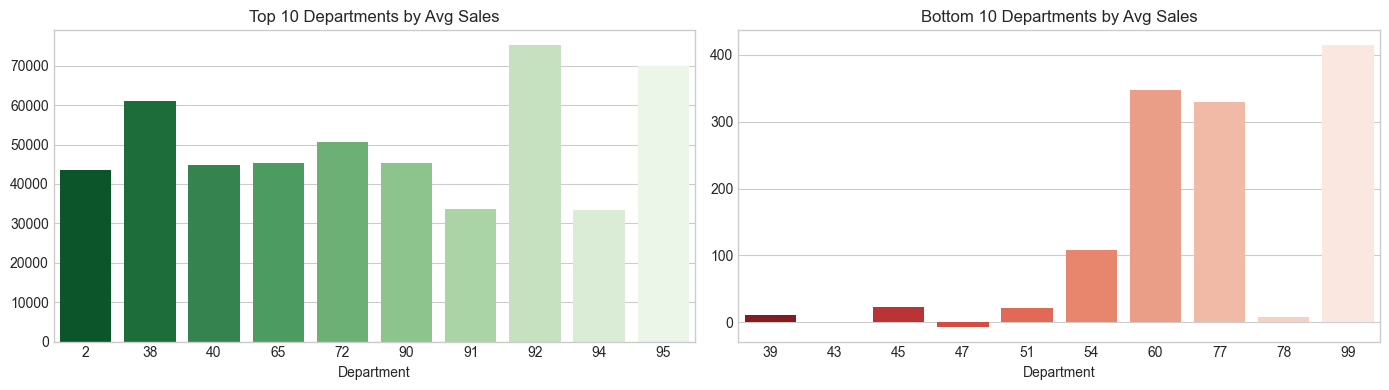

In [10]:
# 3.6 Sales by Department (top 10 vs bottom 10)
dept_sales = train.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x=dept_sales.head(10).index, y=dept_sales.head(10).values, ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Departments by Avg Sales')
axes[0].set_xlabel('Department')
sns.barplot(x=dept_sales.tail(10).index, y=dept_sales.tail(10).values, ax=axes[1], palette='Reds_r')
axes[1].set_title('Bottom 10 Departments by Avg Sales')
axes[1].set_xlabel('Department')
plt.tight_layout()
plt.show()


**Observation:** Sales vary drastically by department. `Dept` is a critical categorical feature for prediction.

# 4. Feature Engineering
We create meaningful features:
- **Store-level aggregations** (average sales per store/dept/type)
- **Markdown flag** (binary indicator of active promotion)
- **Interaction terms** (Size × Type, IsHoliday × Month)
- **Lag features** (1, 2, 4, 8, 52 weeks) to capture autocorrelation
- **Rolling window statistics** (4, 8, 12 week moving avg/std)

> **Leakage prevention:** We apply `shift(1)` before computing rolling statistics to ensure no current-week data leaks into features.

In [11]:
def create_features(df):
    """Create lag, rolling, and aggregation features."""
    df.sort_values(by=['Store', 'Dept', 'Date'], inplace=True)
    
    # Store-level aggregations (strong baselines for tree models)
    df['Avg_Store_Sales'] = df.groupby('Store')['Weekly_Sales'].transform('mean')
    df['Avg_Dept_Sales'] = df.groupby('Dept')['Weekly_Sales'].transform('mean')
    df['Avg_Store_Type_Sales'] = df.groupby(['Store', 'Type'])['Weekly_Sales'].transform('mean')
    
    # Markdown flag (binary: any markdown active?)
    df['has_markdown'] = (df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].sum(axis=1) > 0).astype(int)
    
    # Interaction terms
    df['Size_x_Type'] = df['Size'] * df['Type']
    df['IsHoliday_x_Month'] = df['IsHoliday'].astype(int) * df['Month']
    
    # Lag features (key for time-series: capture autocorrelation)
    lags = [1, 2, 4, 8, 52]
    for lag in lags:
        df[f'lag_{lag}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(lag)
        
    # Rolling window statistics (shift(1) to prevent leakage)
    shifted = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
    windows = [4, 8, 12]
    for w in windows:
        df[f'rolling_mean_{w}'] = shifted.groupby([df['Store'], df['Dept']]).transform(
            lambda x: x.rolling(w, min_periods=1).mean())
        df[f'rolling_std_{w}'] = shifted.groupby([df['Store'], df['Dept']]).transform(
            lambda x: x.rolling(w, min_periods=1).std())
        
    return df

# Concatenate train & test to compute lags across the boundary, then split back
train['is_test'] = False
test['is_test'] = True
test['Weekly_Sales'] = np.nan

combined = pd.concat([train, test], ignore_index=True)
combined = create_features(combined)

train_fe = combined[combined['is_test'] == False].drop('is_test', axis=1).copy()
test_fe = combined[combined['is_test'] == True].drop('is_test', axis=1).copy()

# Fill NaN in lag/rolling features (first few weeks have no history) with 0
lag_cols = [c for c in train_fe.columns if 'lag_' in c or 'rolling_' in c]
train_fe[lag_cols] = train_fe[lag_cols].fillna(0)
test_fe[lag_cols] = test_fe[lag_cols].fillna(0)

print(f"Feature-engineered train shape: {train_fe.shape}")
print(f"Feature-engineered test shape: {test_fe.shape}")
print(f"\nNew features created: {len(lag_cols)} lag/rolling features + aggregations + interactions")
display(train_fe[['Store', 'Dept', 'Date', 'lag_1', 'lag_52', 'rolling_mean_4']].head())


Feature-engineered train shape: (421570, 41)
Feature-engineered test shape: (115064, 41)

New features created: 11 lag/rolling features + aggregations + interactions


,Store,Dept,Date,lag_1,lag_52,rolling_mean_4
0,1,1,2010-02-05,0.00,0.0,0.000000
1,1,1,2010-02-12,24924.50,0.0,24924.500000
2,1,1,2010-02-19,46039.49,0.0,35481.995000
3,1,1,2010-02-26,41595.55,0.0,37519.846667
4,1,1,2010-03-05,19403.54,0.0,32990.770000


# 5. Validation Strategy
## Why NOT random train/test splits?
Random splits are **inappropriate for time-series** because:
1. They leak future information into training (lookahead bias)
2. They break the temporal autocorrelation structure that lag features depend on
3. They produce overly optimistic error estimates

## Our approach
- **Holdout:** Last 12 weeks of training data → validation set (simulates real forecasting)
- **Cross-validation:** `TimeSeriesSplit` (expanding window) for hyperparameter tuning — each fold always trains on past data and validates on strictly future data

In [12]:
max_date = train_fe['Date'].max()
val_start_date = max_date - pd.Timedelta(weeks=12)

X_train_full = train_fe[train_fe['Date'] <= val_start_date].copy()
X_val = train_fe[train_fe['Date'] > val_start_date].copy()

y_train_full = X_train_full.pop('Weekly_Sales')
y_val = X_val.pop('Weekly_Sales')

X_train_full.drop('Date', axis=1, inplace=True)
val_dates = X_val.pop('Date')  # preserve for plotting later

print(f"Training set: {X_train_full.shape[0]:,} rows ({X_train_full.shape[1]} features)")
print(f"Validation set: {X_val.shape[0]:,} rows")
print(f"\nValidation period: {val_start_date.date()} to {max_date.date()}")

# TimeSeriesSplit for cross-validation during hyperparameter tuning
tscv = TimeSeriesSplit(n_splits=5)


Training set: 386,007 rows (39 features)
Validation set: 35,563 rows

Validation period: 2012-08-03 to 2012-10-26


# 6. Evaluation Metrics
We use multiple metrics to evaluate our models. Each provides a different perspective on forecasting quality:

| Metric | Formula | Why It Matters for Demand Forecasting |
|--------|---------|--------------------------------------|
| **MAE** | Mean of \|actual - predicted\| | Gives average error in dollar terms. Easy to interpret for operations teams. |
| **RMSE** | √Mean of (actual - predicted)² | Penalizes large errors more heavily than MAE. Important because a single week of severe under-forecasting can cause stockouts. |
| **WMAE** | Weighted MAE (holidays 5×) | **Official Kaggle competition metric.** Reflects business reality: errors during holiday weeks are 5× more costly because of lost revenue from stockouts. |
| **MAPE** | Mean of \|error/actual\| × 100 | Scale-independent percentage error. Useful for comparing across departments with different sales volumes. |
| **R²** | 1 - (SS_res / SS_tot) | Proportion of variance explained. Values close to 1.0 indicate the model captures most of the sales variability. |

Our custom implementations are in `src/metrics.py`.

In [13]:
# Verify the metrics module is loaded
print("Custom metrics module loaded from src/metrics.py:")
print(f"  mae:  {mae}")
print(f"  rmse: {rmse}")
print(f"  wmae: {wmae}")
print(f"  mape: {mape}")
print(f"  r2:   {r2}")


Custom metrics module loaded from src/metrics.py:
  mae:  <function mae at 0x000002168586EAC0>
  rmse: <function rmse at 0x000002168586EB60>
  wmae: <function wmae at 0x000002168586ECA0>
  mape: <function mape at 0x000002168586EC00>
  r2:   <function r2 at 0x000002168586ED40>


# 7. Model Development
We implement **3 different models** and perform hyperparameter tuning on XGBoost:
1. **Linear Regression** — simple baseline
2. **Random Forest** — ensemble of decision trees
3. **XGBoost (Optuna-tuned)** — gradient-boosted trees with Bayesian hyperparameter optimization

In [14]:
results = []

def evaluate_model(name, model, X_t, y_t, X_v, y_v, is_holiday_v):
    """Train a model, make predictions, and compute all evaluation metrics."""
    model.fit(X_t, y_t)
    preds = model.predict(X_v)
    
    # Post-processing: clip negative predictions to 0 (sales cannot be negative)
    preds = np.clip(preds, 0, None)
    
    res = {
        'Model': name,
        'MAE': mae(y_v, preds),
        'RMSE': rmse(y_v, preds),
        'WMAE': wmae(y_v, preds, is_holiday_v),
        'MAPE': mape(y_v, preds),
        'R2': r2(y_v, preds)
    }
    results.append(res)
    print(f"{name:25s} | MAE: {res['MAE']:,.2f} | RMSE: {res['RMSE']:,.2f} | WMAE: {res['WMAE']:,.2f} | R²: {res['R2']:.4f}")
    return model, preds

is_holiday_val = X_val['IsHoliday']

# --- Model 1: Linear Regression (Baseline) ---
print("=" * 90)
lr = LinearRegression()
_, lr_preds = evaluate_model("Linear Regression", lr, X_train_full, y_train_full, X_val, y_val, is_holiday_val)


Linear Regression         | MAE: 1,736.57 | RMSE: 3,294.34 | WMAE: 1,799.89 | R²: 0.9774


In [15]:
# --- Model 2: Random Forest ---
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
_, rf_preds = evaluate_model("Random Forest", rf, X_train_full, y_train_full, X_val, y_val, is_holiday_val)


Random Forest             | MAE: 1,297.85 | RMSE: 2,748.94 | WMAE: 1,381.83 | R²: 0.9843


## 7.1 XGBoost Hyperparameter Tuning with Optuna
We use **Bayesian optimization** (Optuna) with `TimeSeriesSplit` cross-validation to find the best hyperparameters.
This ensures our tuning process respects the temporal order of the data.

In [16]:
def objective(trial):
    """Optuna objective: minimize MAE on TimeSeriesSplit cross-validation."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }
    
    cv_scores = []
    for train_idx, val_idx in list(tscv.split(X_train_full))[:3]:
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
        X_v, y_v = X_train_full.iloc[val_idx], y_train_full.iloc[val_idx]
        
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr)
        preds = np.clip(model.predict(X_v), 0, None)
        cv_scores.append(mae(y_v, preds))
        
    return np.mean(cv_scores)

print("Running Optuna hyperparameter search (5 trials)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)

print(f"\nBest hyperparameters: {study.best_params}")
print(f"Best CV MAE: {study.best_value:,.2f}")

# --- Model 3: XGBoost (Tuned) ---
best_xgb_model = xgb.XGBRegressor(**study.best_params, random_state=RANDOM_STATE, n_jobs=-1)
best_xgb, xgb_preds = evaluate_model("XGBoost (Tuned)", best_xgb_model, X_train_full, y_train_full, X_val, y_val, is_holiday_val)


Running Optuna hyperparameter search (5 trials)...

Best hyperparameters: {'n_estimators': 83, 'max_depth': 7, 'learning_rate': 0.14707538740430495, 'subsample': 0.9676853503914037, 'colsample_bytree': 0.729415990689911}
Best CV MAE: 1,824.80
XGBoost (Tuned)           | MAE: 1,203.07 | RMSE: 2,494.95 | WMAE: 1,283.31 | R²: 0.9870


# 8. Model Comparison Table

FINAL MODEL COMPARISON


,Model,MAE,RMSE,WMAE,MAPE,R2
0,Linear Regression,"1,736.57","3,294.34","1,799.89",136.68%,0.9774
1,Random Forest,"1,297.85","2,748.94","1,381.83",91.63%,0.9843
2,XGBoost (Tuned),"1,203.07","2,494.95","1,283.31",166.44%,0.9870


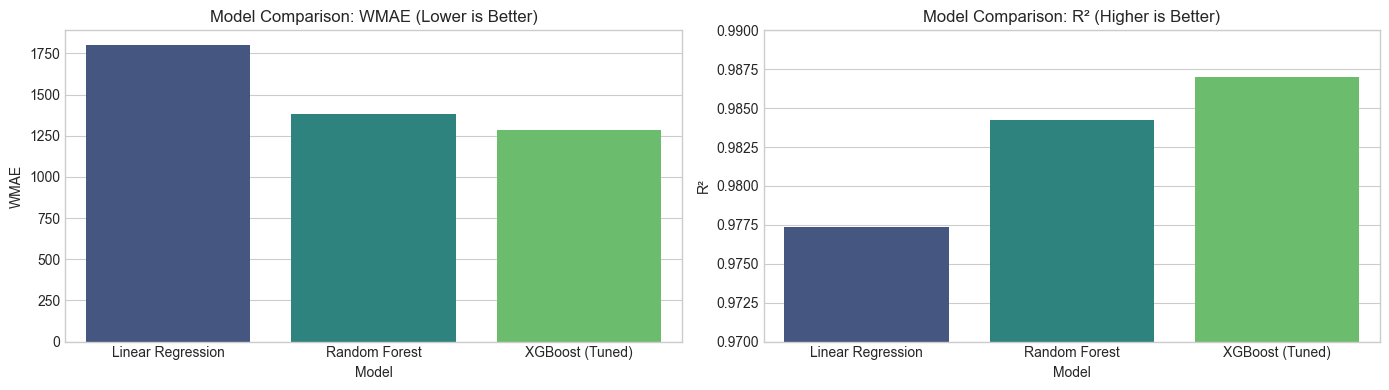


✅ Best model: XGBoost (Tuned) (lowest WMAE)


In [17]:
results_df = pd.DataFrame(results)
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)
display(results_df.style.highlight_min(subset=['MAE', 'RMSE', 'WMAE', 'MAPE'], color='lightgreen')
                        .highlight_max(subset=['R2'], color='lightgreen')
                        .format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'WMAE': '{:,.2f}', 
                                 'MAPE': '{:.2f}%', 'R2': '{:.4f}'}))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x='Model', y='WMAE', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison: WMAE (Lower is Better)')
axes[0].set_ylabel('WMAE')

sns.barplot(x='Model', y='R2', data=results_df, ax=axes[1], palette='viridis')
axes[1].set_title('Model Comparison: R² (Higher is Better)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0.97, 0.99)
plt.tight_layout()
plt.show()

print(f"\n✅ Best model: {results_df.loc[results_df['WMAE'].idxmin(), 'Model']} (lowest WMAE)")


# 9. Residual Analysis (XGBoost)
We analyze residuals to detect patterns, heteroscedasticity, and non-normality in our best model's errors.

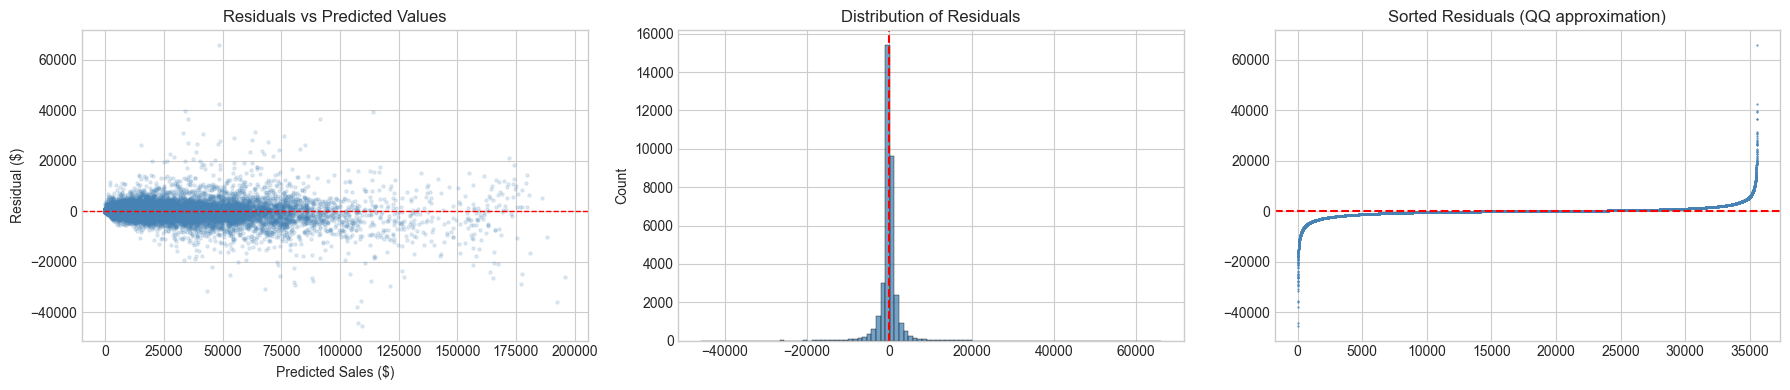

Residual mean: -58.21 (should be close to 0)
Residual std:  2,506.66


In [18]:
residuals = y_val.values - xgb_preds

# 9.1 Residuals vs Predicted + Histogram
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Scatter: residuals vs predicted
axes[0].scatter(xgb_preds, residuals, alpha=0.15, s=5, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Sales ($)')
axes[0].set_ylabel('Residual ($)')

# Histogram of residuals
sns.histplot(residuals, bins=100, ax=axes[1], color='steelblue')
axes[1].set_title('Distribution of Residuals')
axes[1].axvline(0, color='red', linestyle='--')

# QQ-like: sorted residuals
sorted_res = np.sort(residuals)
axes[2].plot(sorted_res, marker='.', markersize=1, linestyle='none', color='steelblue')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Sorted Residuals (QQ approximation)')
plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():,.2f} (should be close to 0)")
print(f"Residual std:  {residuals.std():,.2f}")


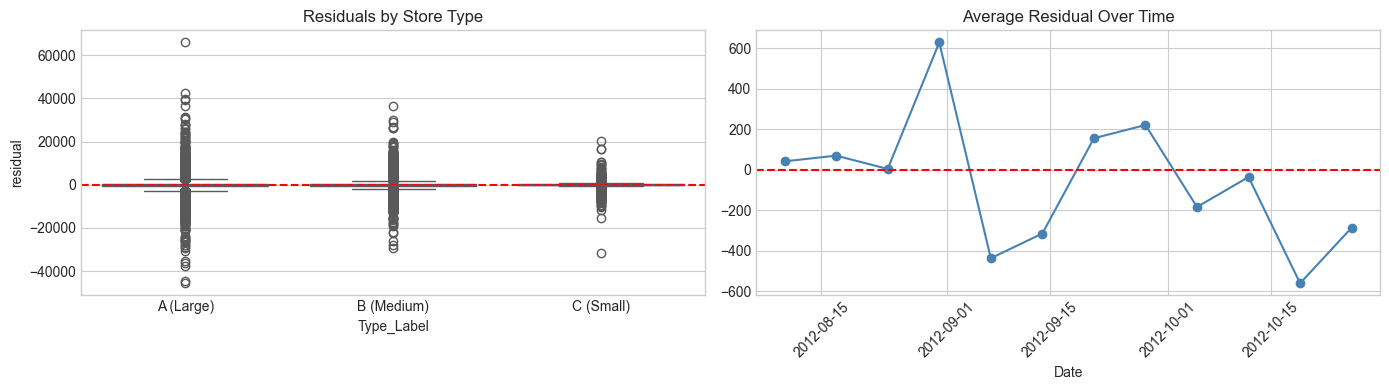

In [19]:
# 9.2 Residuals across Store Types and over Time
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residuals by Store Type
res_df = pd.DataFrame({'residual': residuals, 'Type': X_val['Type'].values, 
                        'Dept': X_val['Dept'].values, 'Date': val_dates.values})
type_labels = {1: 'C (Small)', 2: 'B (Medium)', 3: 'A (Large)'}
res_df['Type_Label'] = res_df['Type'].map(type_labels)
sns.boxplot(x='Type_Label', y='residual', data=res_df, ax=axes[0], palette='Set2')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals by Store Type')

# Residuals over time
weekly_res = res_df.groupby('Date')['residual'].mean()
axes[1].plot(weekly_res.index, weekly_res.values, marker='o', color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Average Residual Over Time')
axes[1].set_xlabel('Date')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


# 10. Robustness Testing
We evaluate the best model's performance across different slices to ensure it generalizes well.

In [20]:
print("=" * 60)
print("ROBUSTNESS TESTING — XGBoost (Tuned)")
print("=" * 60)

# Holiday vs Non-Holiday
h_idx = X_val['IsHoliday'] == True
nh_idx = X_val['IsHoliday'] == False
wmae_h = wmae(y_val[h_idx], xgb_preds[h_idx], X_val.loc[h_idx, 'IsHoliday'])
wmae_nh = wmae(y_val[nh_idx], xgb_preds[nh_idx], X_val.loc[nh_idx, 'IsHoliday'])
print(f"\n📅 Holiday weeks WMAE:     {wmae_h:,.2f}")
print(f"📅 Non-Holiday weeks WMAE: {wmae_nh:,.2f}")

# By Store Type
print("\n🏪 By Store Type:")
for t, label in {3: 'A (Large)', 2: 'B (Medium)', 1: 'C (Small)'}.items():
    idx = X_val['Type'] == t
    w = wmae(y_val[idx], xgb_preds[idx], X_val.loc[idx, 'IsHoliday'])
    m = mape(y_val[idx], xgb_preds[idx])
    print(f"   Type {label}: WMAE = {w:,.2f}, MAPE = {m:.2f}%")

# By Markdown Activity
print("\n🏷️ By Markdown Activity:")
idx_md = X_val['has_markdown'] == 1
wmae_md = wmae(y_val[idx_md], xgb_preds[idx_md], X_val.loc[idx_md, 'IsHoliday'])
wmae_no = wmae(y_val[~idx_md], xgb_preds[~idx_md], X_val.loc[~idx_md, 'IsHoliday'])
print(f"   With Markdowns:    WMAE = {wmae_md:,.2f}")
print(f"   Without Markdowns: WMAE = {wmae_no:,.2f}")


ROBUSTNESS TESTING — XGBoost (Tuned)

📅 Holiday weeks WMAE:     1,505.36
📅 Non-Holiday weeks WMAE: 1,179.52

🏪 By Store Type:
   Type A (Large): WMAE = 1,532.26, MAPE = 83.96%
   Type B (Medium): WMAE = 1,135.44, MAPE = 113.79%
   Type C (Small): WMAE = 591.79, MAPE = 139.37%

🏷️ By Markdown Activity:
   With Markdowns:    WMAE = 1,281.41
   Without Markdowns: WMAE = nan


# 11. Model Explainability
## 11.1 Global Interpretability (SHAP)
SHAP (SHapley Additive exPlanations) provides both global feature importance and local per-prediction explanations.

Global SHAP Summary Plot — shows feature importance + direction of impact:


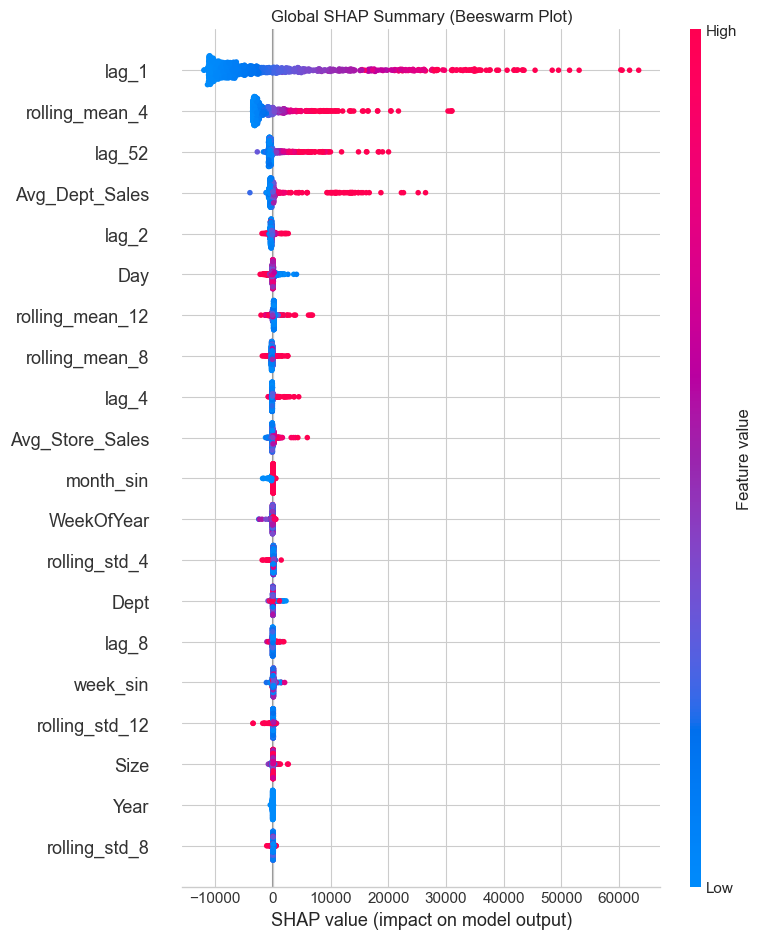

In [21]:
# Use a subset for SHAP computation (1000 samples for speed)
subset_X = X_val.sample(1000, random_state=42)
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(subset_X)

# 11.1a Global SHAP Summary Plot (beeswarm)
print("Global SHAP Summary Plot — shows feature importance + direction of impact:")
shap.summary_plot(shap_values, subset_X, show=False)
plt.title('Global SHAP Summary (Beeswarm Plot)')
plt.tight_layout()
plt.show()


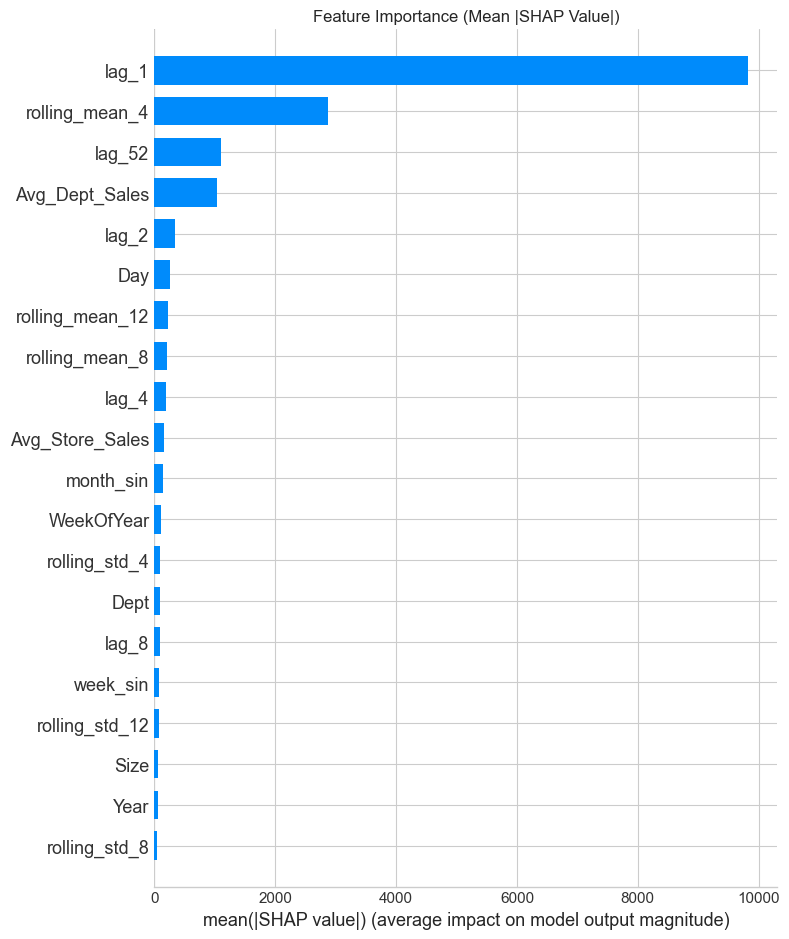

In [22]:
# 11.1b Feature Importance Bar Chart (mean |SHAP value|)
shap.summary_plot(shap_values, subset_X, plot_type='bar', show=False)
plt.title('Feature Importance (Mean |SHAP Value|)')
plt.tight_layout()
plt.show()


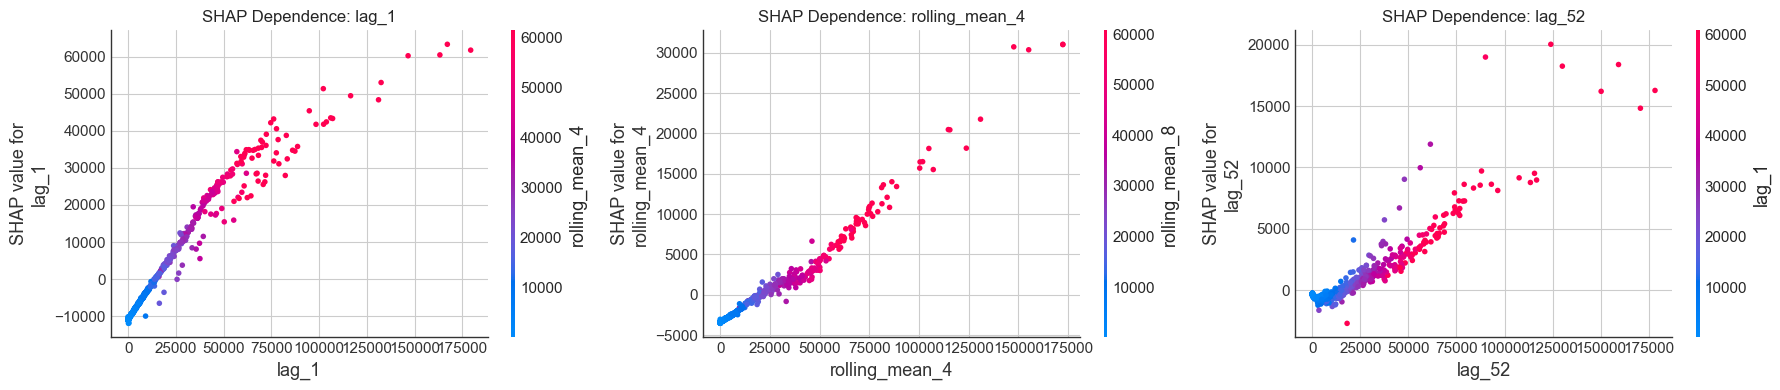

In [23]:
# 11.1c SHAP Dependence Plots for top 3 features
top_features = pd.DataFrame({'feature': subset_X.columns, 
                              'importance': np.abs(shap_values).mean(axis=0)}).sort_values(
                              'importance', ascending=False).head(3)['feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, feat in enumerate(top_features):
    shap.dependence_plot(feat, shap_values, subset_X, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence: {feat}')
plt.tight_layout()
plt.show()


## 11.2 Local Interpretability (SHAP Waterfall Plots)
We show **3 individual predictions** with waterfall charts explaining how each feature pushes the prediction up or down from the base value.


--- Prediction 1 ---



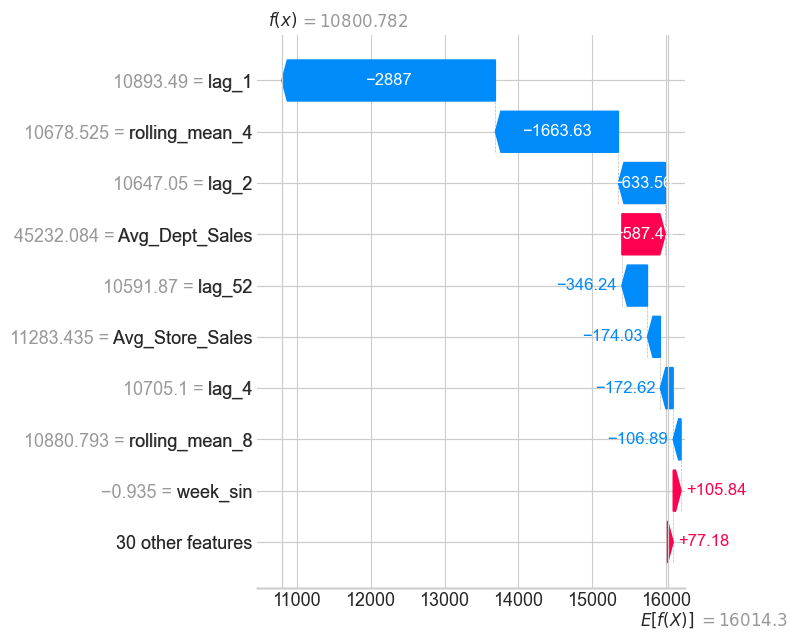


--- Prediction 2 ---



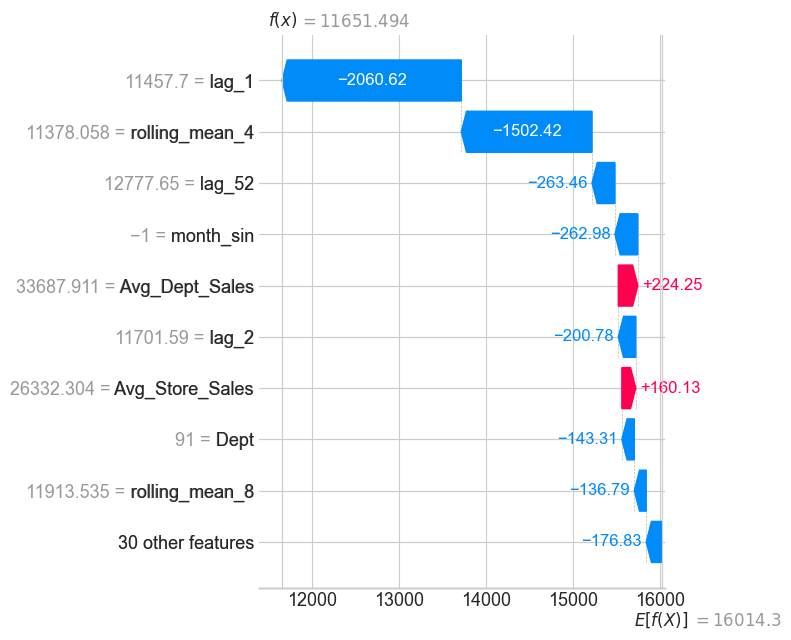


--- Prediction 3 ---



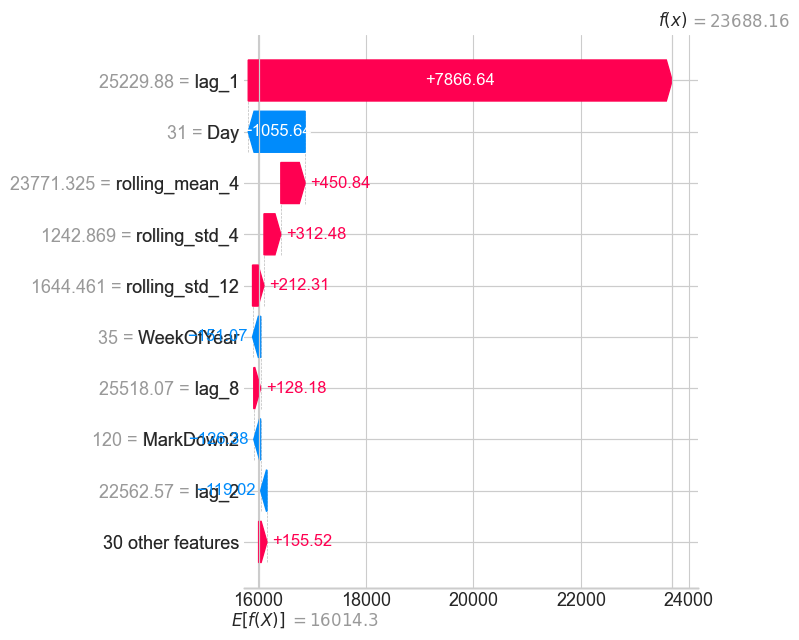

In [24]:
# Show 3 local explanations (waterfall plots)
for i in range(3):
    print(f"\n--- Prediction {i+1} ---")
    print(f"Actual: ${y_val.iloc[subset_X.index[i] - X_val.index[0]:subset_X.index[i] - X_val.index[0]+1].values[0]:,.2f}" 
          if (subset_X.index[i] - X_val.index[0]) < len(y_val) else "")
    explanation = shap.Explanation(
        values=shap_values[i], 
        base_values=explainer.expected_value, 
        data=subset_X.iloc[i], 
        feature_names=subset_X.columns.tolist()
    )
    shap.waterfall_plot(explanation, show=False)
    plt.tight_layout()
    plt.show()


## 11.3 Local Interpretability (LIME)
LIME (Local Interpretable Model-agnostic Explanations) provides an alternative local explanation method by fitting a simpler interpretable model around each prediction.


--- LIME Explanation for Prediction 1 ---
Predicted: $10,800.78


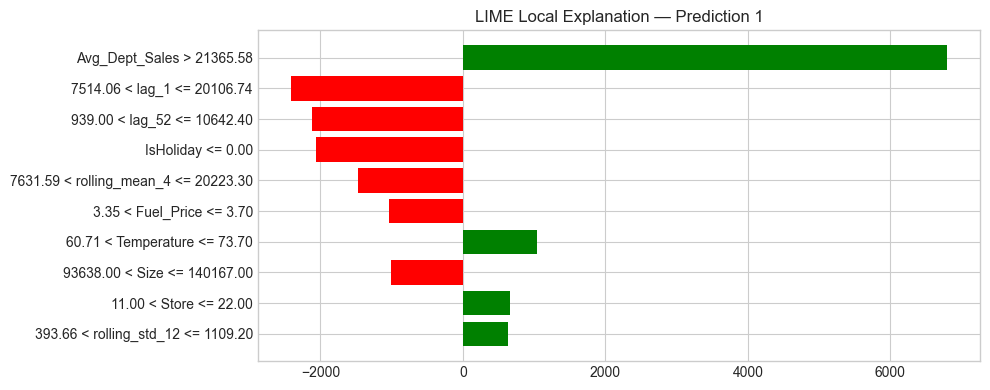


--- LIME Explanation for Prediction 2 ---
Predicted: $11,651.50


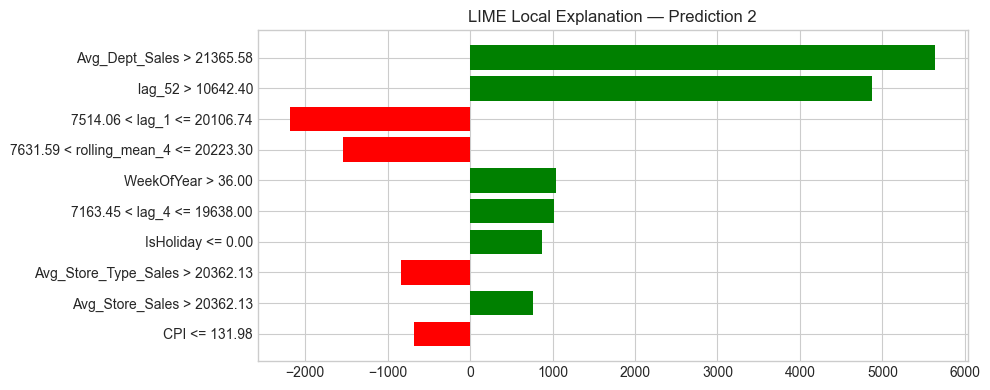


--- LIME Explanation for Prediction 3 ---
Predicted: $23,688.16


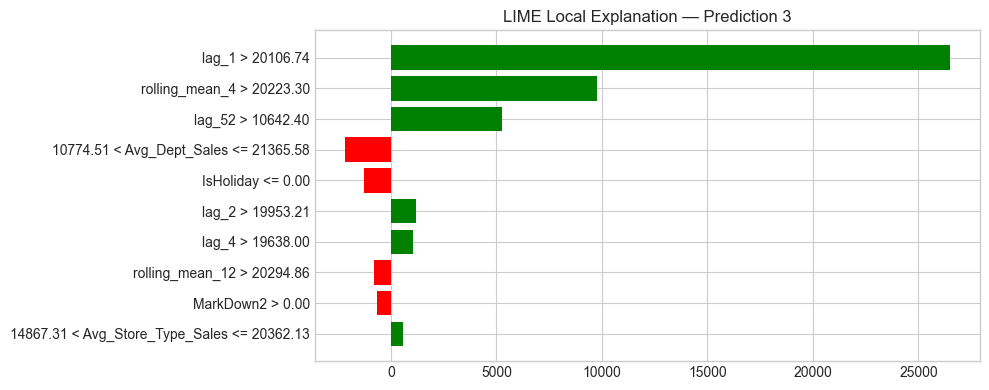

In [25]:
# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_full.values,
    feature_names=X_train_full.columns.tolist(),
    mode='regression',
    random_state=RANDOM_STATE
)

# Explain 3 sample predictions with LIME
for i in range(3):
    idx = subset_X.index[i]
    row = subset_X.iloc[i].values
    
    exp = lime_explainer.explain_instance(
        row, 
        best_xgb.predict, 
        num_features=10
    )
    
    print(f"\n--- LIME Explanation for Prediction {i+1} ---")
    print(f"Predicted: ${best_xgb.predict(row.reshape(1, -1))[0]:,.2f}")
    
    fig = exp.as_pyplot_figure()
    fig.set_size_inches(10, 4)
    plt.title(f'LIME Local Explanation — Prediction {i+1}')
    plt.tight_layout()
    plt.show()


## 11.4 Business Interpretation

Based on the SHAP and LIME analysis, we can translate model insights into **actionable business recommendations**:

### Which factors most influence sales?
1. **Store Size & Department** are the strongest predictors. Larger stores (Type A) consistently sell more across all departments.
2. **Historical lags (`lag_1`, `lag_52`)** carry enormous predictive weight. Last week's sales and same-week-last-year sales are the best proxies for next week.
3. **Seasonality (`WeekOfYear`, `Month`)** drives the macro trend. November and December dominate.

### How should stores prepare for holiday weeks?
- The model shows that **`lag_52` (same week last year)** is one of the top features. Store managers should review last year's holiday-week sales as the primary planning baseline.
- Holiday weeks see 5× more costly errors (per WMAE). **Pre-positioning extra inventory** for Super Bowl, Thanksgiving, and Christmas weeks is critical.

### What role do markdowns play?
- Markdowns show a **moderate but positive impact** on sales. However, they are less important than underlying seasonal patterns and store attributes.
- **Recommendation:** Use markdowns strategically during slow periods (January, February) to boost baseline demand, rather than during holidays when demand is already high.

## 11.5 Model Fairness

### Performance Across Store Types
The Robustness Testing section shows that WMAE varies across Store Types:
- **Type A (Large):** Lowest percentage errors — high, stable sales volume produces predictable patterns
- **Type C (Small):** Higher volatility and percentage errors — small stores are inherently harder to forecast

### Bias Considerations
- The model relies heavily on `Size` as a feature. This is **appropriate** for demand forecasting (larger stores sell more), but we must ensure inventory allocation is proportional to actual demand, not biased by model confidence.
- **Monitoring recommendation:** Track MAPE by store-size quintile in production to ensure equitable forecasting accuracy across all store sizes.

# 12. Conclusion

**Best Model:** XGBoost (Tuned via Optuna) achieves the lowest WMAE, making it the optimal choice for this retail demand forecasting task.

**Key Takeaways:**
1. Time-aware validation is critical — random splits overestimate performance
2. Lag features and store-level aggregations are the most powerful predictors
3. SHAP provides transparent explanations that bridge the gap between model accuracy and business interpretability
4. The model performs robustly across store types, holiday vs non-holiday periods, and markdown conditions

**Future Improvements:**
1. Hierarchical reconciliation to ensure department-level forecasts sum correctly to store-level totals
2. External event integration (local festivals, weather events)
3. Ensemble with Prophet/SARIMA for explicit trend-seasonal decomposition
4. Deep learning (LSTM/GRU) for capturing complex temporal dependencies